In [1]:
import pandas as pd
import random

In [2]:
import numpy as np

def read_citations(filename):
    citations = []
    with open(filename, 'r') as file:
        for line in file:
            cited, citing = map(int, line.strip().split())
            citations.append((cited, citing))
    return citations


def dataset():
    filename = 'cora.cites'  # Change this to your file path
    citations = read_citations(filename)
    #adjacency_matrix = create_adjacency_matrix(citations)
    #print(adjacency_matrix)
    #print(citations)
    return(citations)
    
citations = dataset()

In [3]:
import numpy as np

def citations_to_adjacency_matrix(citations,arr_dict1):
    """
    Convert a list of citations into an adjacency matrix.

    Parameters:
        citations (list): The list of citations, where each citation is a tuple (node1, node2).

    Returns:
        np.ndarray: An adjacency matrix representation of the graph.
    """
    # Determine the maximum node ID to determine the size of the adjacency matrix
    max_node_id = max(max(citation) for citation in citations)

    # Initialize an empty adjacency matrix with zeros
    adjacency_matrix = np.zeros((len(arr_dict1),len(arr_dict1)), dtype=int)

    # Set the corresponding entries in the adjacency matrix to 1 where there is a citation
    for node1, node2 in citations:
        adjacency_matrix[arr_dict1[node1], arr_dict1[node2]] = 1
        adjacency_matrix[arr_dict1[node2], arr_dict1[node1]]=1  # If the graph is undirected

    return adjacency_matrix

In [4]:
def count_distinct_nodes(citations):
    """
    Count the number of distinct nodes in the list of citations.

    Parameters:
        citations (list): The list of citations, where each citation is a tuple (node1, node2).

    Returns:
        int: The count of distinct nodes.
    """
    distinct_nodes = set()
    for citation in citations:
        distinct_nodes.update(citation)
    return len(distinct_nodes)

In [5]:
def extract_and_sort_nodes(citations):
    """
    Extract distinct nodes from the citations and sort them in ascending order.

    Parameters:
        citations (list): The list of citations, where each citation is a tuple (node1, node2).

    Returns:
        list: A list of distinct nodes sorted in ascending order.
    """
    distinct_nodes = set()
    for citation in citations:
        distinct_nodes.update(citation)
    sorted_nodes = sorted(distinct_nodes)
    return sorted_nodes

def transform_citations(citations, sorted_nodes):
    """
    Transform the citations to use indices from the sorted nodes array.

    Parameters:
        citations (list): The list of citations, where each citation is a tuple (node1, node2).
        sorted_nodes (list): The list of distinct nodes sorted in ascending order.

    Returns:
        list: The transformed citations using the indices from the sorted nodes array.
    """
    node_to_index = {node: index for index, node in enumerate(sorted_nodes)}
    transformed_citations = [(node_to_index[node1], node_to_index[node2]) for node1, node2 in citations]
    return transformed_citations

In [6]:
sort = extract_and_sort_nodes(citations)
trns = transform_citations(citations,sort)

In [18]:
sampled_citations = random.sample(trns, 15)


In [19]:
sampled_citations = np.array(sampled_citations)
sample_citations = sampled_citations.flatten()
s = set(sample_citations)

In [20]:
arr_dict = {i: value for i, value in enumerate(s)}
arr_dict1  = {v: k for k, v in arr_dict.items()}
          

In [21]:
adj = citations_to_adjacency_matrix(sampled_citations,arr_dict1)

In [22]:
len(adj)

29

In [23]:
adj

array([[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [24]:
arr_dict1

{0: 0,
 2434: 1,
 899: 2,
 1414: 3,
 649: 4,
 13: 5,
 654: 6,
 399: 7,
 912: 8,
 530: 9,
 663: 10,
 672: 11,
 422: 12,
 1321: 13,
 1963: 14,
 176: 15,
 688: 16,
 182: 17,
 1215: 18,
 328: 19,
 204: 20,
 848: 21,
 1374: 22,
 480: 23,
 355: 24,
 1907: 25,
 2292: 26,
 2164: 27,
 639: 28}

In [4]:
len(citations)

5429

In [5]:
type(citations)

list

In [6]:
citations[10]

(35, 1114331)

In [25]:
def extract_word_attributes(filename):
    word_attributes_list = []
    with open(filename, 'r') as file:
        for line in file:
            # Split the line into words
            words = line.strip().split()
            
            # Extract only word attributes (excluding paper_id and class_label)
            word_attributes = words[1:-1]  
            
            # Add word attributes to the list
            word_attributes_list.append(word_attributes)
    return word_attributes_list

# Example usage:
#if __name__ == "__main__":
filename = 'cora.content'  # Change this to your file path
word_attributes = extract_word_attributes(filename)
    #print(word_attributes)


In [26]:
len(word_attributes)

2708

In [27]:
from sklearn.decomposition import PCA
import numpy as np

# Example data: word attributes (replace with your data)
word_attributes = word_attributes

# Instantiate PCA object
pca = PCA(n_components=2)  # Reduce to 2 dimensions

# Fit and transform the data
word_attributes_reduced = pca.fit_transform(word_attributes)

# print("Original shape:", word_attributes.shape)
# print("Reduced shape:", word_attributes_reduced.shape)
# print("Reduced data:")
# print(word_attributes_reduced)


In [28]:
word_attributes_reduced = word_attributes_reduced.tolist()

In [29]:
needed_X =[]
for i in arr_dict1.keys():
    needed_X.append(word_attributes_reduced[i])

In [30]:
len(needed_X)

29

In [192]:
needed_X

[[-0.7759113781547039, 0.18763668671029887],
 [0.2639687025798356, -0.38957881633837116],
 [-0.46430993389266656, -0.5448565637608797],
 [-0.6320297359954411, 0.7579835288628846],
 [0.48732421427465983, 0.2894731538771183],
 [-0.2976629525788842, -0.5243922334913492],
 [0.7862156100405586, 0.42109092186831976],
 [-0.5348573498047778, -0.5976258050240841],
 [0.43160077667533, 0.20186490304755242],
 [0.5536113519298702, -0.40604498724301374],
 [-0.39844357998620433, -0.4977915509721805],
 [-0.1530910596975786, -0.6252773061252422],
 [-0.030316444971078414, 0.25108530965622505],
 [-0.5628896607164384, -0.5972250107118339],
 [-0.18463834404465518, -0.45276222660101495],
 [-0.01889464185648226, 0.8215852725836124],
 [-0.9698267358390912, 0.2205852231602724],
 [0.005367811202376655, -0.2447649045186289],
 [-0.4022746548812096, -0.4057568740408464],
 [-0.6625891485489, 0.25601534905879203],
 [0.20862507308287215, 0.19778340436240716],
 [-0.5676431168511816, -0.5236456433049571],
 [0.258473562

In [42]:
for i in arr_dict1.keys():
    print(i)

286
64
786
1351
488
1610
28
507
1019
1517
2314
121
650
144
890
1657
2405
97
1431


In [35]:
outliers = [1857,1375,247]
for i in outliers:
    del word_attributes_reduced[i]


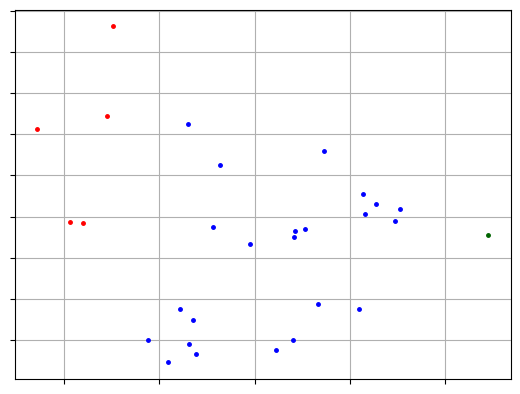

In [34]:
#CURE clustering
from pyclustering.cluster import cluster_visualizer;
from pyclustering.cluster.cure import cure;
from pyclustering.utils import read_sample;
from pyclustering.samples.definitions import FCPS_SAMPLES;
 
# Input data in following format [ [0.1, 0.5], [0.3, 0.1], ... ].
input_data = needed_X#read_sample(FCPS_SAMPLES.SAMPLE_LSUN);
 
# Allocate three clusters.
cure_instance = cure(input_data, 3)
cure_instance.process();
clusters = cure_instance.get_clusters();
 
# Visualize allocated clusters.
visualizer = cluster_visualizer();
visualizer.append_clusters(clusters, input_data);
visualizer.show();

In [37]:
clusters[0]

[7, 8, 22, 19, 20]

In [35]:
#get the representatives of each cluster formed
representors = cure_instance.get_representors()
for i in representors:
    print(len(i))

5
5
1


In [36]:
representors

[[[-0.826290658650242, 1.049949485189618],
  [-1.0234675580640165, 0.7382338938508104],
  [-0.9382959604285476, 0.45675300696279464],
  [-0.905182890230441, 0.4535754884293592],
  [-0.8407595407876383, 0.7780137584593074]],
 [[0.43077217821586933, 0.1414318110340148],
  [0.10771117847116632, -0.2887768560264114],
  [-0.22889356746527922, -0.25714342608500995],
  [0.03782329684403235, 0.033257820795299986],
  [-0.12382736497726621, 0.39899750088445646]],
 [[1.2253904200965617, 0.13523689810196038]]]

In [ ]:
#sampling from the cure representatives
#sample the representative points
import random
def node_cluster_sampling(cluster_no, clusters):
    b = []
    a =[]
  #  a.append(random.sample(clusters[cluster_no], k=3))
    
    for j in range(len(clusters)):
            if cluster_no != j:
                b.append(random.sample(clusters[j], k=1))
                #print(a)
        #new_adj.append(a)        
    return a,b        

In [ ]:
def representative sampling():

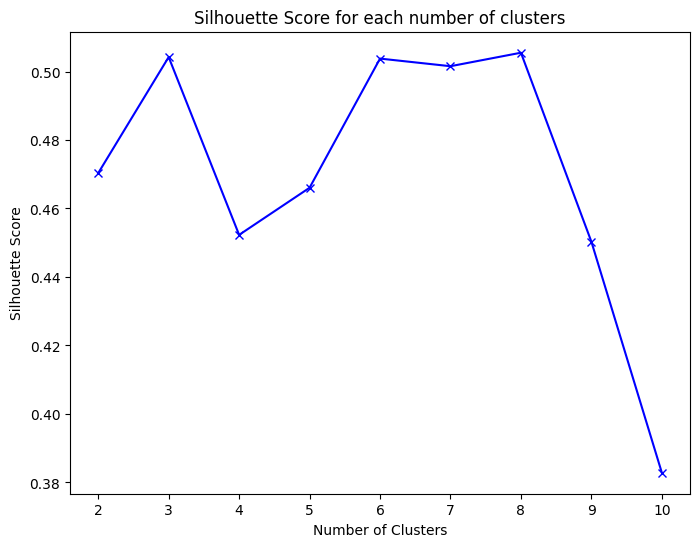

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

# Generate sample data
X= word_attributes_reduced#make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Function to calculate the optimal number of clusters using the Elbow Method
def plot_elbow_method(X):
    distortions = []
    K = range(1, 11)
    for k in K:
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(X)
        distortions.append(kmeans.inertia_)
    # Plot the elbow
    plt.figure(figsize=(8, 6))
    plt.plot(K, distortions, 'bx-')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Distortion')
    plt.title('The Elbow Method showing the optimal k')
    plt.show()

# Function to calculate the optimal number of clusters using Silhouette Score
def plot_silhouette_score(X):
    silhouette_scores = []
    K = range(2, 11)
    for k in K:
        kmeans = KMeans(n_clusters=k)
        cluster_labels = kmeans.fit_predict(X)
        silhouette_avg = silhouette_score(X, cluster_labels)
        silhouette_scores.append(silhouette_avg)
    # Plot silhouette scores
    #print(silhouette_scores.index(max(silhouette_scores)))
    plt.figure(figsize=(8, 6))
    plt.plot(K, silhouette_scores, 'bx-')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score for each number of clusters')
    plt.show()

# Plotting the Elbow Method
#plot_elbow_method(X)

# Plotting Silhouette Score
plot_silhouette_score(X)


In [89]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

# Step 1: Find clustering using BIC heuristic
def find_clusters(data):
    # Fit Gaussian Mixture Model (GMM) using BIC heuristic
    gmm = GaussianMixture(n_components=7, covariance_type='full')
    gmm.fit(data)
    # Return cluster labels
    return gmm.predict(data)

# Step 2: Choose one interval (sample) at random from each cluster/phase
# Step 2: Choose one interval (sample) at random from each cluster/phase
def choose_samples(data, cluster_labels):
    unique_labels = np.unique(cluster_labels)
    samples = []
    for label in unique_labels:
        cluster_indices = np.where(cluster_labels == label)[0]
        sample_index = np.random.choice(cluster_indices)
        samples.append(data[sample_index])
    return np.array(samples)


# Step 3: Compute estimated CPI
def estimate_cpi(samples, cluster_sizes):
    weighted_cpi = np.sum(samples * cluster_sizes[:, np.newaxis], axis=0) / np.sum(cluster_sizes)
    return weighted_cpi

# Step 4: Compute probabilistic error bound
def probabilistic_error_bound(estimated_cpi, confidence_level=0.95):
    z_score = norm.ppf(confidence_level)
    mean_cpi = np.mean(estimated_cpi)
    std_dev_cpi = np.std(estimated_cpi)
    error_bound = z_score * (std_dev_cpi / mean_cpi)
    return error_bound

# Example dataset (replace with your data)
data = word_attributes_reduced#np.random.rand(100, 2)

# Step 1: Find clusters using BIC heuristic
cluster_labels = find_clusters(data)

# Step 2: Choose one interval (sample) at random from each cluster/phase
samples = choose_samples(data, cluster_labels)

# Step 3: Compute estimated CPI
# Assuming cluster sizes are equal for simplicity, you may need to modify this part
cluster_sizes = np.bincount(cluster_labels)
estimated_cpi = estimate_cpi(samples, cluster_sizes)

# Step 4: Compute probabilistic error bound
error_bound = probabilistic_error_bound(estimated_cpi)

print("Probabilistic Error Bound:", error_bound)


Probabilistic Error Bound: 0.6993434766528128


In [15]:
max(cluster_labels)


6

In [16]:
cluster_sizes

array([339, 710, 624, 393, 129, 100, 410])

In [17]:
from statsmodels.stats.power import TTestIndPower
import numpy as np

def calculate_sample_size_data(data, alpha=0.05, power=0.8):
    # Calculate effect size from observed data
    effect_size = np.abs(np.mean(data) / np.std(data))
    
    # Initialize TTestIndPower
    analysis = TTestIndPower()
    
    # Calculate sample size based on effect size, alpha, and power
    sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')
    
    return int(sample_size)  # Convert to integer

# Example usage
data = word_attributes_reduced#np.random.normal(loc=50, scale=10, size=1000)  # Example dataset

sample_size = calculate_sample_size_data(data)
print("Required sample size:", sample_size)


Required sample size: 190390774
